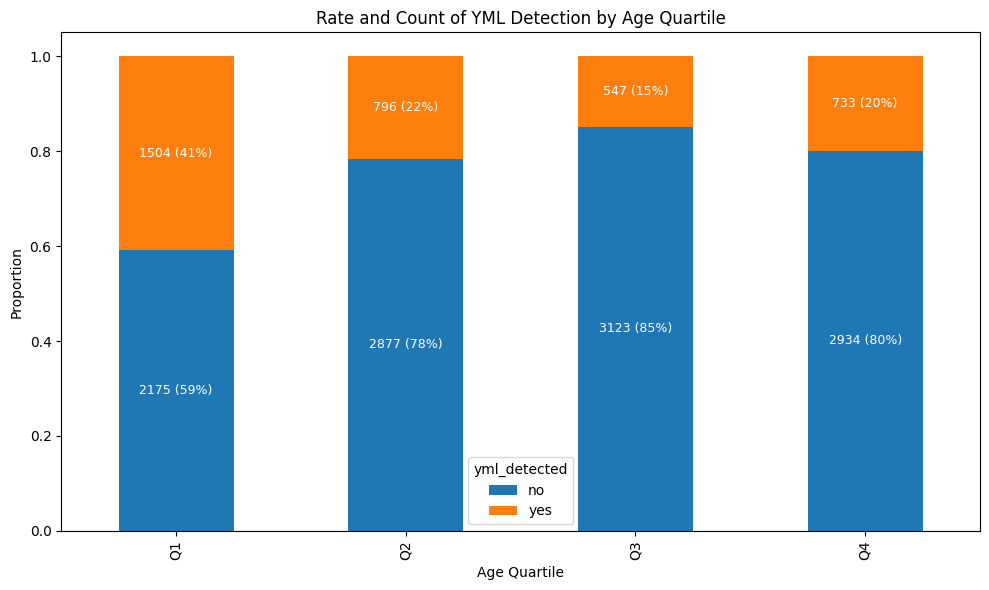

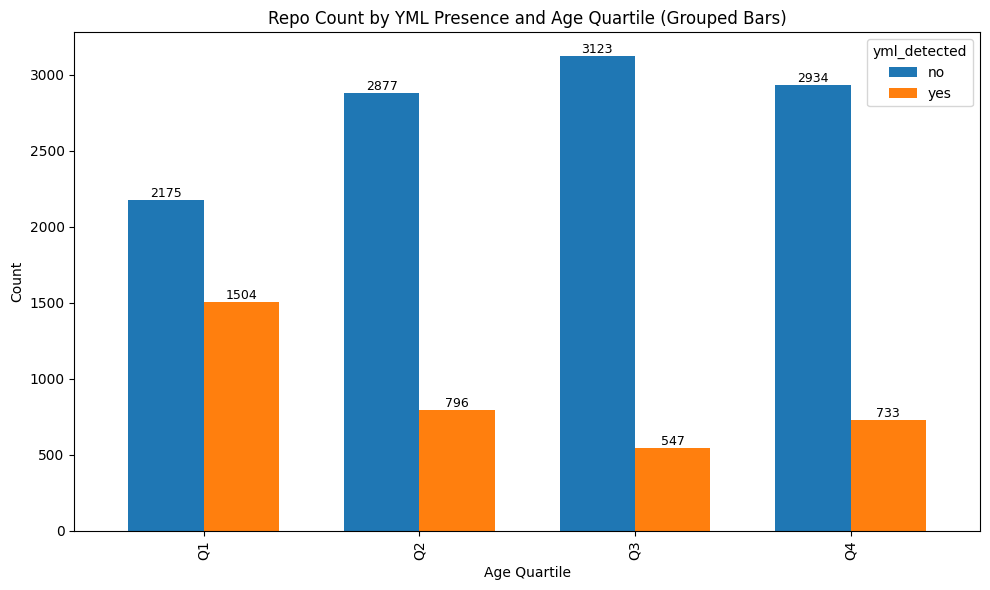

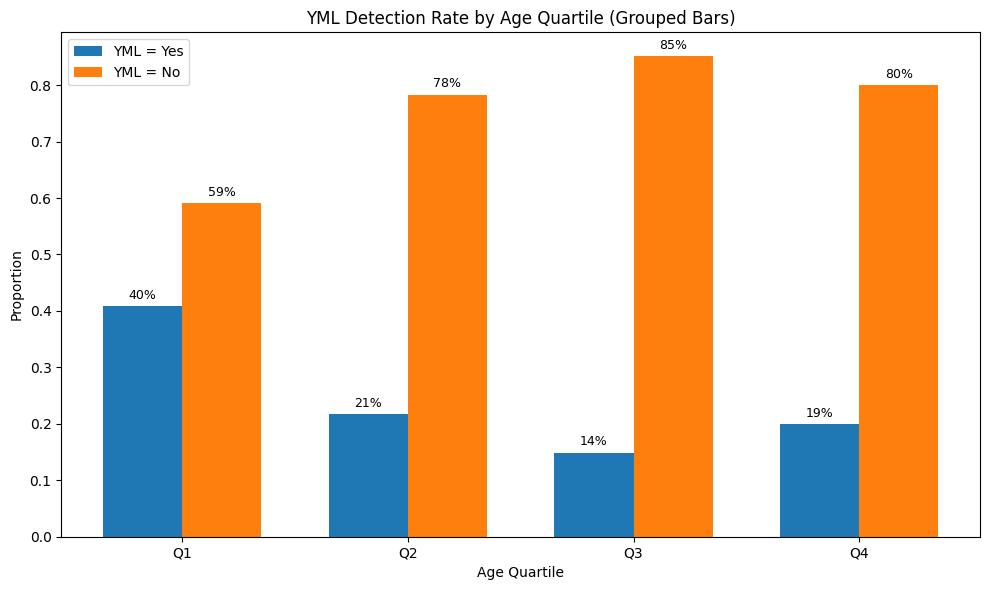

YML Presence Summary:
yml_detected
no     11109
yes     3580
Name: count, dtype: int64

Average Age (Years) by YML Status:
yml_detected
no     7.37
yes    6.04
Name: repo_age_years, dtype: float64

Filtered dataset saved to: C:\Android Mobile App\Step1_URL_Search\Type_1_Searching_Pipeline_July 15\Selected_Repos.csv


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# === File and Folder Setup ===
folder_path = r"C:\Android Mobile App\Step1_URL_Search\Type_1_Searching_Pipeline_July 14"
input_file = os.path.join(folder_path, "step4_ci_detection_output.csv")
output_file = os.path.join(folder_path, "Selected_Repos.csv")

# === Load CSV ===
df = pd.read_csv(input_file)

# === Step 1: Filter for valid repos ===
df_filtered = df[df['Valid_Repo_Step3'] == 'yes'].copy()

# === Step 2: Keep only rows with yml_detected = "yes" or "no"
df_filtered = df_filtered[df_filtered['yml_detected'].isin(['yes', 'no'])].copy()

# === Step 3: Calculate repo age in years ===
search_date = pd.to_datetime("2025-07-14").tz_localize("UTC")
df_filtered['created_at'] = pd.to_datetime(df_filtered['created_at'], errors='coerce')
df_filtered['repo_age_years'] = ((search_date - df_filtered['created_at']).dt.total_seconds()) / (365.25 * 24 * 3600)
df_filtered['repo_age_years'] = df_filtered['repo_age_years'].round(2)

# === Step 4: Age Quartiles ===
df_filtered['age_quartile'] = pd.qcut(df_filtered['repo_age_years'], 4, labels=["Q1", "Q2", "Q3", "Q4"])

# === Step 5: Bar Chart - Rate and Count with Labels (Stacked) ===
rate_plot = (
    df_filtered
    .groupby('age_quartile', observed=True)['yml_detected']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

count_plot = (
    df_filtered
    .groupby('age_quartile', observed=True)['yml_detected']
    .value_counts()
    .unstack()
    .fillna(0)
)

ax = rate_plot.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Rate and Count of YML Detection by Age Quartile')
plt.ylabel('Proportion')
plt.xlabel('Age Quartile')

# Add count and percent labels
for i, quartile in enumerate(rate_plot.index):
    for j, label in enumerate(['yes', 'no']):
        if label in rate_plot.columns:
            proportion = rate_plot.loc[quartile, label]
            count = int(count_plot.loc[quartile, label])
            if proportion > 0:
                ax.text(
                    i,
                    rate_plot.loc[quartile, :label].sum() - proportion / 2,
                    f"{count} ({proportion:.0%})",
                    ha='center',
                    va='center',
                    fontsize=9,
                    color='white'
                )

plt.tight_layout()
plt.show()

# === Step 6: Grouped Bar Chart for Count Distribution ===
dist_plot = count_plot
ax2 = dist_plot.plot(kind='bar', stacked=False, figsize=(10, 6), width=0.7)
plt.title('Repo Count by YML Presence and Age Quartile (Grouped Bars)')
plt.ylabel('Count')
plt.xlabel('Age Quartile')

# Add labels above bars
for bars in ax2.containers:
    ax2.bar_label(bars, fmt='%d', label_type='edge', fontsize=9)

plt.tight_layout()
plt.show()

# yml detected by age####################
import numpy as np

# === Compute Rate (Proportion) DataFrame ===
rate_df = (
    df_filtered
    .groupby('age_quartile', observed=True)['yml_detected']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .reindex(columns=['yes', 'no'])  # Ensure consistent order
)

# === Plot Two-Series Grouped Bar Chart (Rate) ===
x = np.arange(len(rate_df.index))  # the label locations
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rate_df['yes'], width, label='YML = Yes')
bars2 = ax.bar(x + width/2, rate_df['no'], width, label='YML = No')

# === Add Labels Above Bars ===
for bars in [bars1, bars2]:

    ax.bar_label(bars, labels=[f"{int(p * 100)}%" for p in bars.datavalues], padding=3, fontsize=9)


# === Format Plot ===
ax.set_title('YML Detection Rate by Age Quartile (Grouped Bars)')
ax.set_xlabel('Age Quartile')
ax.set_ylabel('Proportion')
ax.set_xticks(x)
ax.set_xticklabels(rate_df.index)
ax.legend()

plt.tight_layout()
plt.show()



# === Step 7: Summary Statistics ===
print("YML Presence Summary:")
print(df_filtered['yml_detected'].value_counts())
print("\nAverage Age (Years) by YML Status:")
print(df_filtered.groupby('yml_detected')['repo_age_years'].mean().round(2))

# === Step 8: Save Cleaned Dataset ===
df_filtered.to_csv(output_file, index=False)
print(f"\nFiltered dataset saved to: {output_file}")




In [7]:
# Show the quartile boundary values used by pd.qcut
quartile_bins = pd.qcut(df_filtered['repo_age_years'], 4, retbins=True)[1]
print("Quartile Cut Points (repo age in years):")
for i in range(4):
    print(f"Q{i+1}: {quartile_bins[i]:.2f} to {quartile_bins[i+1]:.2f} years")


Quartile Cut Points (repo age in years):
Q1: 0.53 to 4.94 years
Q2: 4.94 to 7.24 years
Q3: 7.24 to 9.21 years
Q4: 9.21 to 16.65 years


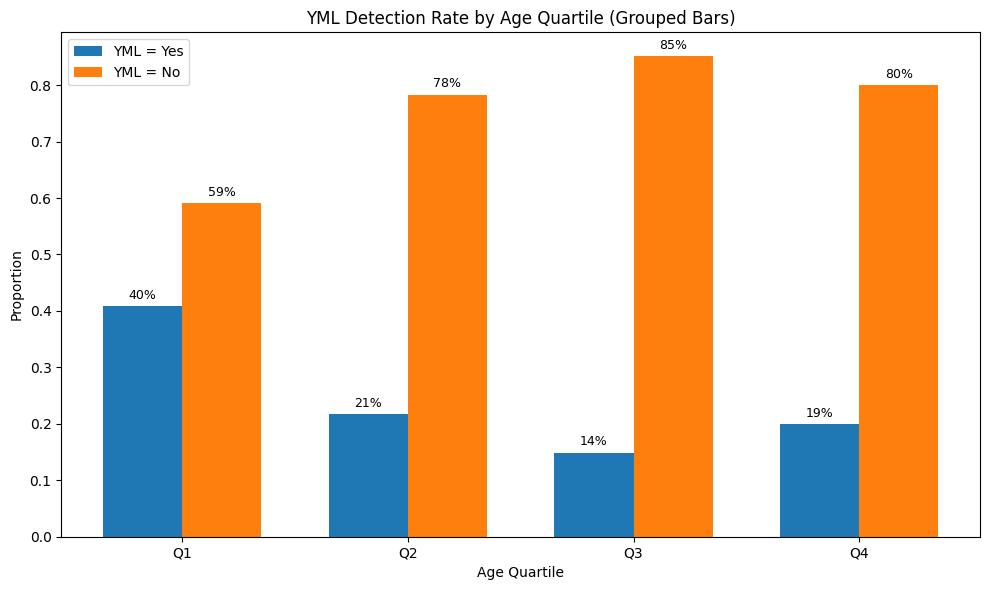

In [12]:
import numpy as np

# === Compute Rate (Proportion) DataFrame ===
rate_df = (
    df_filtered
    .groupby('age_quartile', observed=True)['yml_detected']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    .reindex(columns=['yes', 'no'])  # Ensure consistent order
)

# === Plot Two-Series Grouped Bar Chart (Rate) ===
x = np.arange(len(rate_df.index))  # the label locations
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rate_df['yes'], width, label='YML = Yes')
bars2 = ax.bar(x + width/2, rate_df['no'], width, label='YML = No')

# === Add Labels Above Bars ===
for bars in [bars1, bars2]:

    ax.bar_label(bars, labels=[f"{int(p * 100)}%" for p in bars.datavalues], padding=3, fontsize=9)


# === Format Plot ===
ax.set_title('YML Detection Rate by Age Quartile (Grouped Bars)')
ax.set_xlabel('Age Quartile')
ax.set_ylabel('Proportion')
ax.set_xticks(x)
ax.set_xticklabels(rate_df.index)
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# it counts the number of repositories with different CI services and programming languages
# and saves the summary statistics to CSV files as optional outputs
# it counts by the priority of searching to prevent double counting repos.

import pandas as pd

# === File Path ===
input_path = r"C:\Android Mobile App\Step1_URL_Search\Type_1_Searching_Pipeline_July 14\step4_ci_detection_output.csv"

# === Load dataset ===
df = pd.read_csv(input_path)

# === Filter for valid repos ===
valid_df = df[df["Valid_Repo_Step4"] == "yes"].copy()

# === Language Grouping ===
def map_language(lang):
    if pd.isna(lang):
        return "Other"
    lang = lang.strip().lower()
    if "java" in lang:
        return "Java"
    elif "kotlin" in lang:
        return "Kotlin"
    elif "dart" in lang:
        return "Dart"
    else:
        return "Other"

valid_df["Language_Group"] = valid_df["language"].apply(map_language)
language_summary = valid_df["Language_Group"].value_counts().reset_index()
language_summary.columns = ["Language", "Repo Count"]

# === CI Service Grouping ===
def map_ci(ci):
    if pd.isna(ci):
        return "Unknown"
    ci = ci.lower()
    if "github" in ci:
        return "GitHub Actions"
    elif "travis" in ci:
        return "Travis CI"
    elif "circle" in ci:
        return "CircleCI"
    elif "gitlab" in ci:
        return "GitLab CI"
    elif "bitrise" in ci:
        return "Bitrise"
    elif "azure" in ci:
        return "Azure Pipelines"
    elif "jenkins" in ci:
        return "Jenkins"
    else:
        return "Other"

valid_df["CI_Service_Group"] = valid_df["CI_Service"].apply(map_ci)
ci_summary = valid_df["CI_Service_Group"].value_counts().reset_index()
ci_summary.columns = ["CI Service", "Repo Count"]

# === Save or Display Output (Optional) ===
language_summary.to_csv("language_summary.csv", index=False)
ci_summary.to_csv("ci_service_summary.csv", index=False)


print("📊 Language Summary:")
print(language_summary)
print("\n📊 CI Service Summary:")
print(ci_summary)


📊 Language Summary:
  Language  Repo Count
0   Kotlin        1204
1     Java        1169
2    Other         650
3     Dart         557

📊 CI Service Summary:
        CI Service  Repo Count
0   GitHub Actions        2614
1        Travis CI         769
2         CircleCI         131
3        GitLab CI          37
4            Other          22
5  Azure Pipelines           7


In [2]:
import pandas as pd

# === File path ===
input_path = r"C:\Android Mobile App\Step1_URL_Search\Type_1_Searching_Pipeline_July 14\step4_ci_detection_output.csv"

# === Load dataset ===
df = pd.read_csv(input_path)

# === Filter for valid repos only ===
df_valid = df[df["Valid_Repo_Step4"] == "yes"].copy()

# === Language grouping function ===
def map_language(lang):
    if pd.isna(lang):
        return "Other"
    lang = lang.strip().lower()
    if "java" in lang:
        return "Java"
    elif "kotlin" in lang:
        return "Kotlin"
    elif "dart" in lang:
        return "Dart"
    else:
        return "Other"

df_valid["Language_Group"] = df_valid["language"].apply(map_language)

# === Android keyword grouping ===
df_valid["Android_Keyword_Flag"] = df_valid["Android_keyword"].apply(lambda x: "yes" if str(x).strip().lower() == "yes" else "no")

# === Create matrix ===
language_android_matrix = pd.crosstab(df_valid["Language_Group"], df_valid["Android_Keyword_Flag"])

# === Optional: add row/column totals ===
language_android_matrix["Total"] = language_android_matrix.sum(axis=1)
language_android_matrix.loc["Total"] = language_android_matrix.sum()

# === Output matrix ===
print(language_android_matrix)


Android_Keyword_Flag   no   yes  Total
Language_Group                        
Dart                  195   362    557
Java                   69  1100   1169
Kotlin                 49  1155   1204
Other                   0   650    650
Total                 313  3267   3580


In [4]:
# it counts total CI Servies 

import pandas as pd

# === File Path ===
input_path = r"C:\Android Mobile App\Step1_URL_Search\Type_1_Searching_Pipeline_July 14\step4_ci_detection_output.csv"

# === Load dataset ===
df = pd.read_csv(input_path)

# === Filter for valid repos ===
valid_df = df[df["Valid_Repo_Step4"] == "yes"].copy()

# === Split CI_Service by comma into lists ===
valid_df["CI_Service_List"] = valid_df["CI_Service"].fillna("").apply(lambda x: [ci.strip().lower() for ci in x.split(",") if ci.strip()])

# === Explode to long format (1 row per CI service per repo) ===
exploded = valid_df.explode("CI_Service_List")

# === Map each CI string to a known group ===
def normalize_ci(ci):
    if not ci or ci == "nan":
        return "Unknown"
    if "github" in ci:
        return "GitHub Actions"
    elif "travis" in ci:
        return "Travis CI"
    elif "circle" in ci:
        return "CircleCI"
    elif "gitlab" in ci:
        return "GitLab CI"
    elif "bitrise" in ci:
        return "Bitrise"
    elif "azure" in ci:
        return "Azure Pipelines"
    elif "jenkins" in ci:
        return "Jenkins"
    else:
        return "Other"

exploded["CI_Service_Group"] = exploded["CI_Service_List"].apply(normalize_ci)

# === Group and count all CI services ===
ci_service_summary = exploded["CI_Service_Group"].value_counts().reset_index()
ci_service_summary.columns = ["CI Service", "Repo Count"]

# === Save or display results ===
ci_service_summary.to_csv("multi_ci_service_summary.csv", index=False)

print("📊 Accurate CI Service Usage (Multi-CI Support):")
print(ci_service_summary)


📊 Accurate CI Service Usage (Multi-CI Support):
        CI Service  Repo Count
0   GitHub Actions        2614
1        Travis CI         907
2         CircleCI         220
3            Other         148
4        GitLab CI          94
5  Azure Pipelines          26
6          Bitrise           8



📊 Quartile Cut Points (Repo Age in Years):
0.25    4.71
0.50    7.07
0.75    9.57
Name: repo_age_years, dtype: float64


C:\Users\gilla\AppData\Local\Temp\ipykernel_7580\1927853343.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


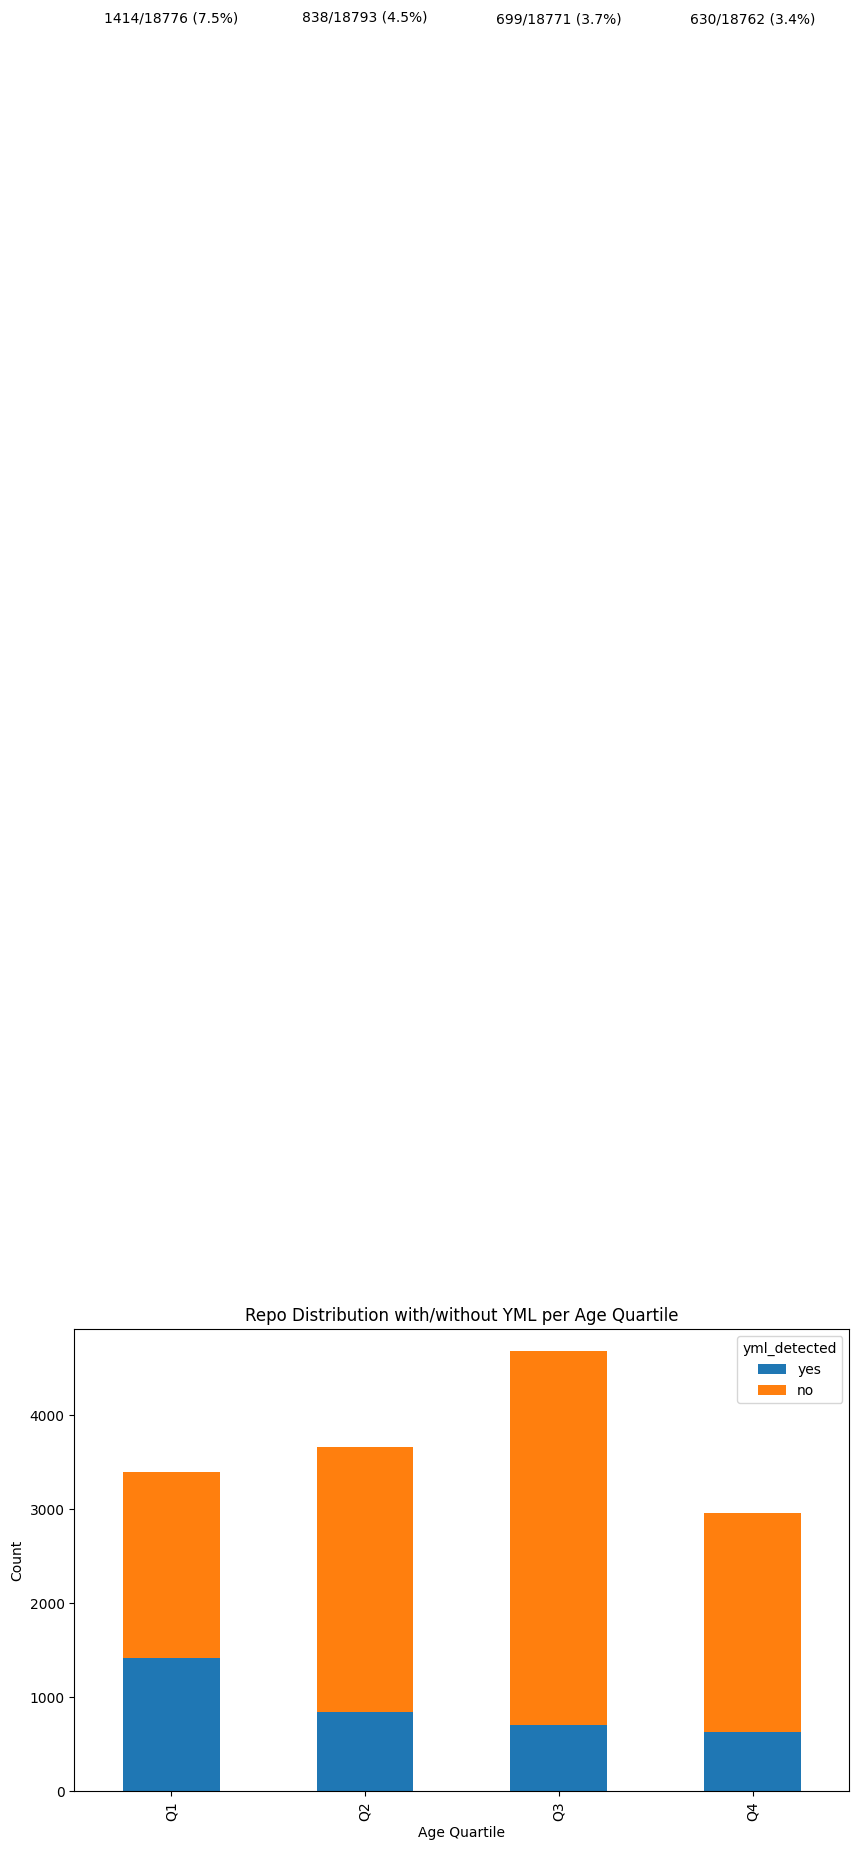

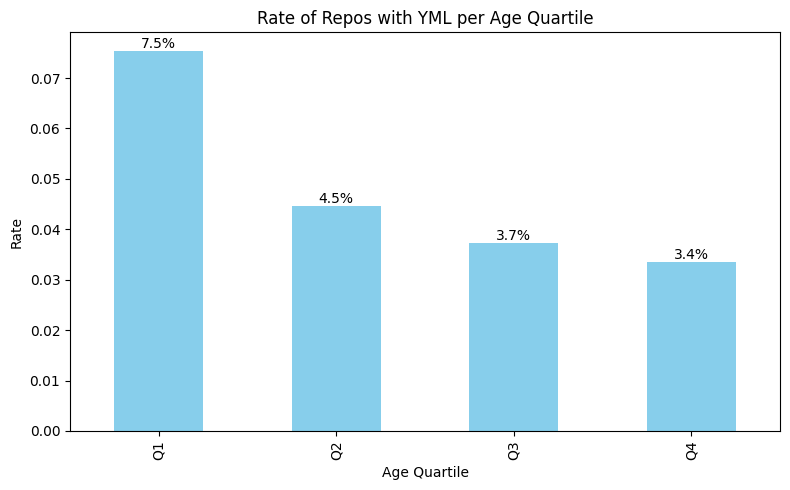

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
%matplotlib inline

# === Step 1: Load file ===
file_path = r"C:\Android Mobile App\Step1_URL_Search\Type_1_Searching_Pipeline_July 14\step4_ci_detection_output.csv"
df = pd.read_csv(file_path)

# === Step 2: Create repo age in years ===
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce').dt.tz_localize(None)
reference_date = pd.to_datetime("2025-07-14")
df['repo_age_years'] = (reference_date - df['created_at']).dt.days / 365.25
df = df.dropna(subset=['repo_age_years'])

# Compute quartiles in years
quartiles = df['repo_age_years'].quantile([0.25, 0.5, 0.75])
df['age_quartile'] = pd.qcut(df['repo_age_years'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# === Step 3: Save updated file ===
df.to_csv(file_path, index=False)

# === Step 4: Summary of Quartiles ===
print("\n📊 Quartile Cut Points (Repo Age in Years):")
print(quartiles.round(2))

# === Step 5: Group by quartile and YML detection ===
grouped = df.groupby(['age_quartile', 'yml_detected'], observed=False).size().unstack(fill_value=0)


grouped['total'] = grouped.sum(axis=1)
grouped['yml_rate'] = grouped.get('yes', 0) / grouped['total']
grouped_reset = grouped.reset_index()

# === Chart 1: Stacked Bar for YML/No YML per Quartile ===
ax1 = grouped_reset.plot(
    x='age_quartile', 
    y=['yes', 'no'], 
    kind='bar', 
    stacked=True, 
    figsize=(10, 6),
    title='Repo Distribution with/without YML per Age Quartile'
)
for idx, row in grouped_reset.iterrows():
    ax1.text(idx, row['total'], f"{int(row.get('yes', 0))}/{int(row['total'])} ({row['yml_rate']:.1%})", ha='center', va='bottom')
ax1.set_ylabel("Count")
ax1.set_xlabel("Age Quartile")
plt.tight_layout()
plt.show()

# === Chart 2: Bar for YML Detection Rate ===
ax2 = grouped_reset.plot(
    x='age_quartile',
    y='yml_rate',
    kind='bar',
    color='skyblue',
    legend=False,
    figsize=(8, 5),
    title='Rate of Repos with YML per Age Quartile'
)
for idx, rate in enumerate(grouped_reset['yml_rate']):
    ax2.text(idx, rate, f"{rate:.1%}", ha='center', va='bottom')
ax2.set_ylabel("Rate")
ax2.set_xlabel("Age Quartile")
plt.tight_layout()
plt.show()
